In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import os
from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, accuracy_score, roc_auc_score
import numpy as np
from collections import Counter

In [3]:
class MicrobialInteractionDataset(Dataset):
    def __init__(self, df, model_type="bpt_large", layer=-1):
        self.df = df.reset_index(drop=True)
        self.model_type = model_type
        self.embedding_cache = {}
        self.layer = layer

        self.unique_carbons = df['Carbon'].unique().tolist()
        self.carbon_to_id = {c: i for i, c in enumerate(self.unique_carbons)}

        unique_classes = sorted(df['Class'].unique())
        self.class_to_id = {c: i for i, c in enumerate(unique_classes)}

        self.n_environments = len(self.unique_carbons)

        # print(f"Dataset: {len(df)} samples, {self.n_environments} environments, {len(unique_classes)} classes")

    def _load_embedding(self, bug_id):
        if bug_id in self.embedding_cache:
            return self.embedding_cache[bug_id]
        path = f"/orange/juannanzhou/bacteria_genome/interaction_data_genome_embeddings_{self.model_type}/{bug_id}_blm_all_layers.pt"
        if self.model_type == 'esm':
            emb = torch.load(path).float()
        else:
            emb = torch.load(path).float()[self.layer]
        self.embedding_cache[bug_id] = emb
        return emb

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        proteins_A = self._load_embedding(row['Bug 1']).mean(0).float().cpu()
        proteins_B = self._load_embedding(row['Bug 2']).mean(0).float().cpu()
        pApB = proteins_A*proteins_B
        env_id = torch.tensor(self.carbon_to_id[row['Carbon']], dtype=torch.long)
        env_onehot = F.one_hot(env_id, num_classes=self.n_environments).float()
        pairwise = torch.cat([proteins_A, proteins_B, pApB, env_onehot], dim=0)

        interaction_type = torch.tensor(self.class_to_id[row['Class']], dtype=torch.long)
        interaction_strength = torch.tensor(row['Strength'], dtype=torch.float32)

        return {
            'pairwise': pairwise,
            'interaction_type': interaction_type,
            'interaction_strength': interaction_strength
        }


In [4]:
from torch.utils.data import DataLoader
import torch

def merge_dataset(dataset, batch_size=64, num_workers=0):
    """
    Merge all batches from MicrobialInteractionDataset into full X, y_type, y_strength.
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    X_all, y_type_all, y_strength_all = [], [], []

    for batch in loader:
        X_all.append(batch['pairwise'])
        y_type_all.append(batch['interaction_type'])
        y_strength_all.append(batch['interaction_strength'])

    X = torch.cat(X_all, dim=0)
    y_type = torch.cat(y_type_all, dim=0)
    y_strength = torch.cat(y_strength_all, dim=0)

    return X, y_type, y_strength


def filter_rare_classes(X, y, k):
    if torch.is_tensor(y):
        y = y.cpu().tolist()

    counts = Counter(y)
    keep = [cls for cls, c in counts.items() if c >= k]
    mask = np.isin(y, keep)

    if torch.is_tensor(X):
        X = X[mask]
        y = torch.tensor(np.array(y)[mask])
    else:
        X, y = X[mask], np.array(y)[mask]

    new_counts = Counter(y.tolist() if torch.is_tensor(y) else y)
    # print(f"{len(y)} samples, {len(new_counts)} classes")
    # print("Class counts:", dict(new_counts))

    return X, y

def logistic_regression_cv(X, y, Cs=np.logspace(-3, 3, 10), k=5, max_iter=5000, seed=42):
    model = LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=max_iter
    )
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    # cv = StratifiedShuffleSplit(n_splits=k, random_state=seed)
    grid = GridSearchCV(model, {'C': Cs}, scoring='f1_macro', cv=cv, n_jobs=-1, refit=True)
    grid.fit(X, y)

    best_model = grid.best_estimator_
    best_C = grid.best_params_['C']

    # manual metrics on each fold
    f1s, accs, aucs = [], [], []
    for train_idx, val_idx in tqdm(cv.split(X, y), desc=f'{k} fold CV', leave=False):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        m = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs',
                               max_iter=max_iter)
        m.fit(X_train, y_train)

        y_pred = m.predict(X_val)
        y_proba = m.predict_proba(X_val)

        f1s.append(f1_score(y_val, y_pred, average='macro'))
    # print(f1s)
    metrics = {
        'F1': np.mean(f1s)
    }
    return best_model, best_C, metrics

In [5]:
from tqdm.notebook import tqdm
import pandas as pd
import pickle

def get_num_layers(emb_type):
    if emb_type == 'bpt_large':
        return 20
    if emb_type == 'bpt_small':
        return 11
    if emb_type == 'esm':
        return 1

df = pd.read_csv("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/species_interaction/data/env_pairwise_data/idatas.csv")
k = 3
seeds = [42, 54, 23, 45, 578]
# structure: env_vs_f1[seed][model][env][layer] = F1
env_vs_f1 = {}

for seed in tqdm(seeds, desc="Seeds"):
    env_vs_f1[seed] = {'esm': {}, 'bpt_large': {}, 'bpt_small': {}}
    for model_type in tqdm(['esm', 'bpt_large', 'bpt_small'], desc=f"Models (seed={seed})", leave=False):
        for layer in tqdm(range(get_num_layers(model_type)), desc=f"Layers ({model_type})", leave=False):
            for env in tqdm(df.Carbon.unique(), desc="Environments", leave=False):
                try:
                    df_env = df[df.Carbon == env].copy()
                    df_env['pair'] = df_env.apply(lambda r: tuple(sorted([r['Bug 1'], r['Bug 2']])), axis=1)
                    df_env = df_env.drop_duplicates(subset=['pair', 'Carbon', 'Class', 'Strength']).drop(columns='pair')

                    dataset = MicrobialInteractionDataset(df_env, model_type=model_type, layer=layer)
                    X, y_type, y_strength = merge_dataset(dataset)
                    X, y_type = filter_rare_classes(X, y_type, k)
                    best_model, best_c, metrics = logistic_regression_cv(X, y_type, k=k, seed=seed)

                    env_vs_f1[seed][model_type].setdefault(env, {})
                    env_vs_f1[seed][model_type][env][layer] = metrics['F1']
                except ValueError:
                    continue

with open("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/species_interaction/results/env_vs_f1_all_seeds.pkl", "wb") as f:
    pickle.dump(env_vs_f1, f)


Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Models (seed=42):   0%|          | 0/3 [00:00<?, ?it/s]

Layers (esm):   0%|          | 0/1 [00:00<?, ?it/s]

Environments:   0%|          | 0/40 [00:00<?, ?it/s]

3 fold CV: 0it [00:00, ?it/s]

...

3 fold CV: 0it [00:00, ?it/s]

3 fold CV: 0it [00:00, ?it/s]

3 fold CV: 0it [00:00, ?it/s]

3 fold CV: 0it [00:00, ?it/s]

3 fold CV: 0it [00:00, ?it/s]

In [7]:
env_vs_f1

{42: {'esm': {'ArabinoseL': {0: 0.8469604469604469},
   'Xylose': {0: 0.41615791615791614},
   'Ribose': {0: 0.5463351463351463},
   'Rhamnose': {0: 0.3466490299823633},
   'Fructose': {0: 0.3498677248677249},
   'Galactose': {0: 0.6801146384479718},
   'Glucose': {0: 0.3055555555555555},
   'Glucose01': {0: 0.4448292448292448},
   'Mannose': {0: 0.5155270655270655},
   'GlcNAc': {0: 0.8036556036556036},
   'Acetate': {0: 0.44166666666666665},
   'Pyruvate': {0: 0.7641554867561059},
   'Pyruvate01': {0: 0.720899470899471},
   'Fumarate': {0: 0.5448148148148148},
   'Succinate': {0: 0.3433333333333333},
   'Citrate': {0: 0.5554584304584305},
   'Glycerol': {0: 0.46560846560846564},
   'Glycerol01': {0: 0.691468253968254},
   'Mannitol': {0: 0.6444444444444445},
   'Sorbitol': {0: 0.40295815295815296},
   'Alanine': {0: 0.2891975308641976},
   'Serine': {0: 0.34435786435786425},
   'Proline': {0: 0.43851851851851853},
   'Proline01': {0: 0.3522222222222222},
   'Glutamine': {0: 0.3064814

In [10]:
import pickle
import numpy as np
import pandas as pd

# with open("env_vs_f1_all_seeds.pkl", "rb") as f:
#     env_vs_f1 = pickle.load(f)

models = ['esm', 'bpt_large', 'bpt_small']

all_envs = sorted({
    env
    for seed in env_vs_f1
    for model in models
    for env in env_vs_f1[seed][model].keys()
})

rows = []
for model in models:
    for env in all_envs:
        per_seed_best = []
        for seed in env_vs_f1:
            layer_dict = env_vs_f1[seed][model].get(env, {})
            if not layer_dict:
                continue
            best_layer = max(layer_dict, key=layer_dict.get)
            per_seed_best.append(layer_dict[best_layer])
        if per_seed_best:
            mean_f1 = np.mean(per_seed_best)
            std_f1 = np.std(per_seed_best)
            rows.append([model, env, mean_f1, std_f1])

df_summary = pd.DataFrame(rows, columns=['Model', 'Environment', 'Mean_F1', 'Std_F1'])
df_summary = df_summary.sort_values(['Environment', 'Model']).reset_index(drop=True)
print(df_summary)

# df_summary.to_csv("env_best_layer_mean_std.csv", index=False)


         Model Environment   Mean_F1    Std_F1
0    bpt_large     Acetate  0.451993  0.039137
1    bpt_small     Acetate  0.458228  0.032143
2          esm     Acetate  0.425423  0.042831
3    bpt_large     Alanine  0.369484  0.056543
4    bpt_small     Alanine  0.342617  0.048162
..         ...         ...       ...       ...
106  bpt_small     Uridine  0.624891  0.021346
107        esm     Uridine  0.615507  0.029989
108  bpt_large      Xylose  0.544228  0.048108
109  bpt_small      Xylose  0.492759  0.047235
110        esm      Xylose  0.430452  0.032215

[111 rows x 4 columns]


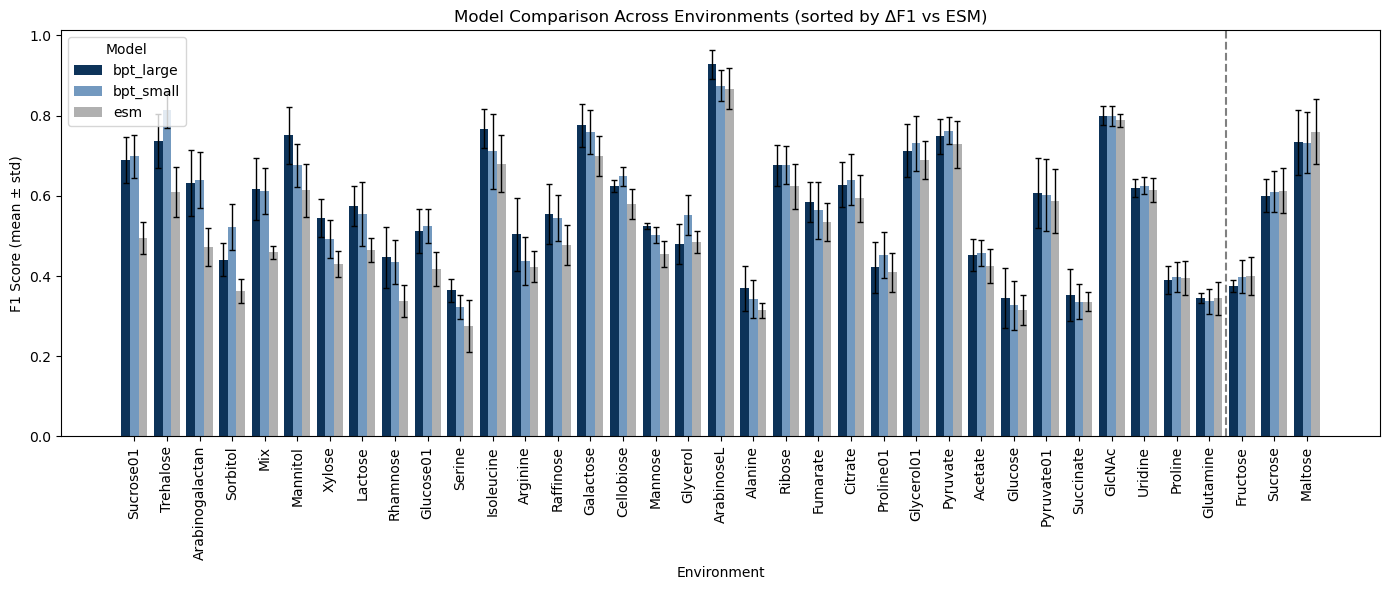

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- compute sort order by ΔF1 vs ESM ---
pivot = df_summary.pivot(index="Environment", columns="Model", values="Mean_F1")
pivot["Δ_large_esm"] = pivot["bpt_large"] - pivot["esm"]
pivot["Δ_small_esm"] = pivot["bpt_small"] - pivot["esm"]
pivot["max_Δ"] = pivot[["Δ_large_esm", "Δ_small_esm"]].max(axis=1)

# Sort environments by largest ΔF1
pivot_sorted = pivot.sort_values("max_Δ", ascending=False)
sorted_envs = pivot_sorted.index.tolist()
df_sorted = df_summary.copy()
df_sorted["Environment"] = pd.Categorical(df_sorted["Environment"], categories=sorted_envs, ordered=True)
df_sorted = df_sorted.sort_values(["Environment", "Model"])

# Define model order and colors
model_order = ["bpt_large", "bpt_small", "esm"]
palette = {"bpt_large": "#003366", "bpt_small": "#6699CC", "esm": "#B0B0B0"}

# --- find where esm starts to win ---
cross_idx = np.where(pivot_sorted["max_Δ"].values < 0)[0]
vline_pos = cross_idx[0] - 0.5 if len(cross_idx) > 0 else None

# --- plot ---
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=df_sorted,
    x="Environment",
    y="Mean_F1",
    hue="Model",
    hue_order=model_order,
    errorbar=None,
    palette=palette,
)

# add error bars properly
for i, model in enumerate(model_order):
    model_data = df_sorted[df_sorted["Model"] == model]
    container = ax.containers[i]
    xs = [bar.get_x() + bar.get_width() / 2 for bar in container]
    ax.errorbar(xs, model_data["Mean_F1"], yerr=model_data["Std_F1"],
                fmt="none", ecolor="black", elinewidth=1, capsize=2, zorder=3)

# draw vertical dashed line where esm overtakes
if vline_pos is not None:
    ax.axvline(x=vline_pos, color="grey", linestyle="--", linewidth=1.5)
    # plt.text(vline_pos + 0.3, 0.95, "ESM wins →", color="grey", fontsize=9, va="top")

plt.xticks(rotation=90)
plt.ylabel("F1 Score (mean ± std)")
plt.title("Model Comparison Across Environments (sorted by ΔF1 vs ESM)")
plt.legend(title="Model", loc="best")
plt.tight_layout()
plt.show()


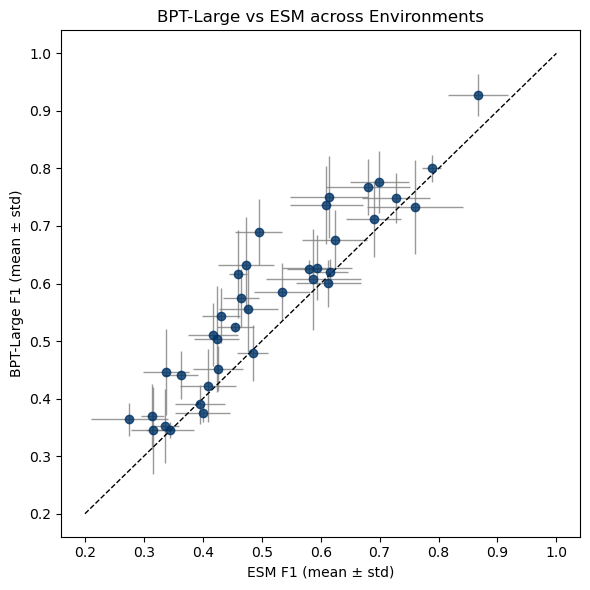

In [20]:
# Keep only bpt_large and esm
df_filtered = df_summary[df_summary["Model"].isin(["bpt_large", "esm"])]

# Pivot for scatter comparison
pivot = df_filtered.pivot(index="Environment", columns="Model", values=["Mean_F1", "Std_F1"])
pivot = pivot.dropna()

# Extract values
x = pivot["Mean_F1"]["esm"]
y = pivot["Mean_F1"]["bpt_large"]
xerr = pivot["Std_F1"]["esm"]
yerr = pivot["Std_F1"]["bpt_large"]

# Scatter plot with error bars
plt.figure(figsize=(6, 6))
plt.errorbar(
    x, y,
    xerr=xerr, yerr=yerr,
    fmt='o', ecolor='gray', capsize=0, elinewidth=1, alpha=0.8,
    color="#003366"
)

# Reference line y=x
plt.plot([0.2, 1], [0.2, 1], 'k--', linewidth=1)

plt.xlabel("ESM F1 (mean ± std)")
plt.ylabel("BPT-Large F1 (mean ± std)")
plt.title("BPT-Large vs ESM across Environments")
plt.tight_layout()
plt.show()
